# Importing Libraries

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Datasets

In [86]:
customers = pd.read_csv('../data/processed/customers_cleaned.csv')
orders = pd.read_csv('../data/processed/orders_cleaned.csv')
order_items = pd.read_csv('../data/processed/order_items_cleaned.csv')
sellers = pd.read_csv('../data/processed/sellers_cleaned.csv')
products = pd.read_csv('../data/processed/products_cleaned.csv')
product_category = pd.read_csv('../data/processed/product_category_cleaned.csv')

# Logistics Analysis

In [87]:
# Dataframe de logistica
df_logistics = orders.merge(order_items, on='order_id', how='left')
df_logistics = df_logistics.merge(products[['product_id', 'product_category_name', 'product_weight_g']], on='product_id', how='left')
df_logistics = df_logistics.merge(product_category, on='product_category_name', how='left')
df_logistics = df_logistics.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')
df_logistics = df_logistics.merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='left')

In [88]:
# Convertendo colunas de data para datetime
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date'
]

for col in date_columns:
    if col in df_logistics.columns:
        df_logistics[col] = pd.to_datetime(df_logistics[col])

In [89]:
df_logistics.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'product_category_name', 'product_weight_g',
       'product_category_name_english', 'customer_state', 'seller_state'],
      dtype='str')

## 1. Average Delivery Time by Customer State

In [90]:
df_logistics.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'product_category_name', 'product_weight_g',
       'product_category_name_english', 'customer_state', 'seller_state'],
      dtype='str')

In [91]:
# Qual o tempo medio de entrega por estado do cliente?
df_logistics['tempo_entrega'] = (
    df_logistics['order_delivered_customer_date'] - df_logistics['order_purchase_timestamp']
).dt.days

In [92]:
tempo_medio_estado = df_logistics.groupby('customer_state')['tempo_entrega'].mean().sort_values(ascending=False).round(1).to_frame()
tempo_medio_estado

,tempo_entrega
customer_state,
RR,27.8
AP,27.8
AM,26.0
AL,24.0
PA,23.3
MA,21.2
SE,21.0
CE,20.5
AC,20.3


> **Insight:** estados do Norte tem tempo de entrega 3x maior que Sao Paulo
> (27.8 vs 8.3 dias), explicando diretamente as piores avaliacoes encontradas
> na analise de satisfacao.

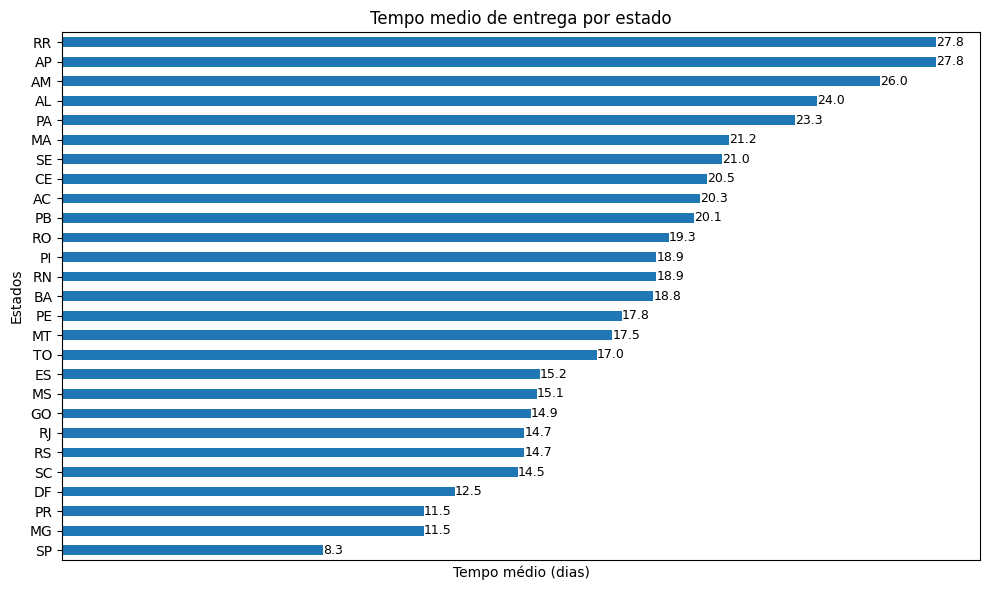

In [93]:
ax = tempo_medio_estado.sort_values(by= 'tempo_entrega', ascending=True).plot(kind='barh', figsize=(10, 6))
plt.title('Tempo medio de entrega por estado')
plt.xlabel('Tempo médio (dias)')
plt.ylabel('Estados')

for bar in ax.patches:
    ax.text(
        bar.get_width(),                    
        bar.get_y() + bar.get_height() / 2, 
        f'{(bar.get_width()):,.1f}',
        va='center',
        ha='left',
        fontsize=9
    )

plt.legend().remove()
plt.xticks(rotation=45, ha='right')
plt.xticks([])
plt.tight_layout()
plt.show()

## 2. States with Most Delays

In [94]:
# Quais estados tem mais atrasos?
df_logistics['entrega_status'] = np.where(
    df_logistics['order_delivered_customer_date'] > df_logistics['order_estimated_delivery_date'],
    'Atrasado',
    'No prazo'
)

In [95]:
df_logistics[df_logistics['entrega_status'] == 'Atrasado'].groupby('customer_state')['entrega_status'].count().sort_values(ascending=False).to_frame()

,entrega_status
customer_state,
SP,2679
RJ,1835
MG,704
BA,504
RS,422
SC,394
ES,272
PR,270
CE,218


SP tem mais atrasos em quantidade absoluta porque também tem muito mais pedidos.
Para uma análise mais justa, vou calcular o percentual de atrasos por estado

In [96]:
total_por_estado = df_logistics.groupby('customer_state')['entrega_status'].count()
atrasos_por_estado = df_logistics[df_logistics['entrega_status'] == 'Atrasado'].groupby('customer_state')['entrega_status'].count()

atraso_pct = (atrasos_por_estado / total_por_estado * 100).round(1).sort_values(ascending=False).to_frame().head(10)
atraso_pct

,entrega_status
customer_state,
AL,23.1
MA,19.6
SE,15.6
PI,14.9
CE,14.7
BA,13.2
RJ,12.5
PA,12.1
ES,12.0


> **Insight:** Alagoas lidera com 23.1% de atrasos, quase 5x mais que Sao Paulo
> (5.6%). Estados do Norte e Nordeste concentram os maiores percentuais de atraso,
> explicando diretamente os piores tempos de entrega e notas dessa regiao.

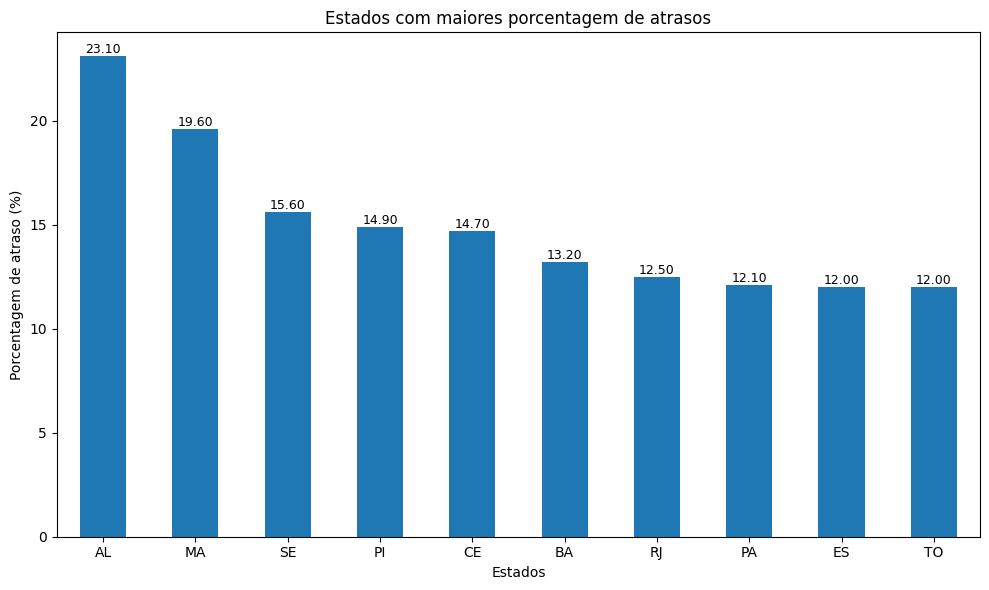

In [97]:
ax = atraso_pct.plot(kind='bar', figsize=(10, 6))
plt.title('Estados com maiores porcentagem de atrasos')
plt.xlabel('Estados')
plt.ylabel('Porcentagem de atraso (%)')

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height(),                    
        f'{(bar.get_height()):,.2f}',      
        va='bottom',
        ha='center',
        fontsize=9
    )

plt.xticks(rotation=0)
plt.legend().remove()
plt.tight_layout()
plt.show()

## 3. Estimated vs Real Delivery Time

In [98]:
# Qual a diferenca entre prazo estimado e prazo real de entrega?
df_logistics['estimado_real'] = (
    df_logistics['order_delivered_customer_date'] - df_logistics['order_estimated_delivery_date']
).dt.days

In [99]:
conditions = [
    df_logistics['estimado_real'] < 0,
    df_logistics['estimado_real'] == 0,
    df_logistics['estimado_real'] > 0
]

choices = [
    'Antes do Prazo',
    'No Prazo',
    'Atrasado'
]

df_logistics['status_estimado_real'] = np.select(conditions, choices, default='Sem Informacao')

In [100]:
status = df_logistics.groupby('status_estimado_real')['status_estimado_real'].count().to_frame()
status

,status_estimado_real
status_estimado_real,
Antes do Prazo,101481
Atrasado,7265
No Prazo,1450
Sem Informacao,3229


> **Insight:** 90.5% dos pedidos sao entregues antes do prazo estimado,
> indicando que a Olist adota uma estrategia de prazos conservadores para
> gerenciar expectativas do cliente. Apenas 6.5% dos pedidos atrasam de fato.

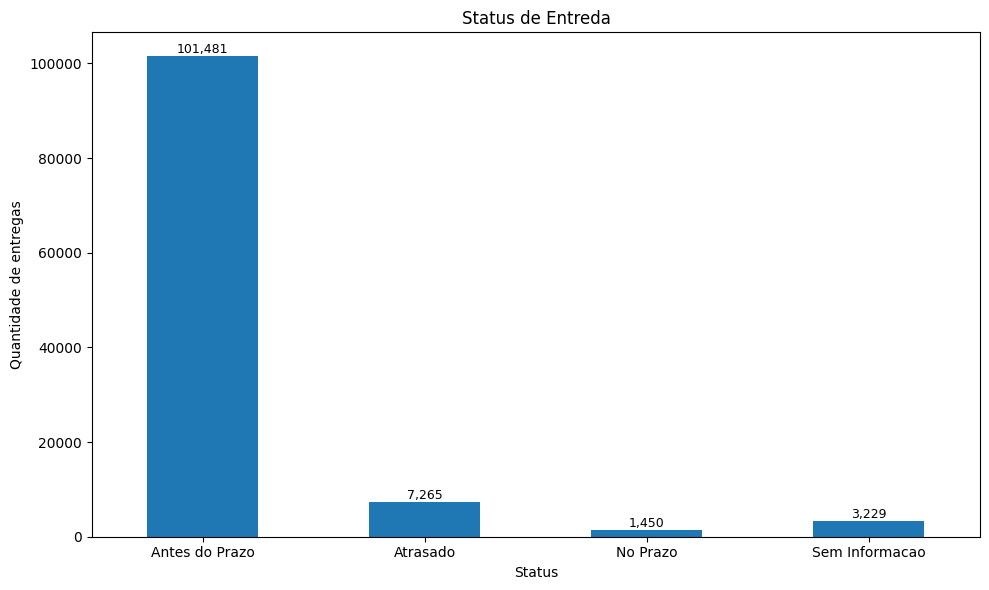

In [101]:
ax = status.plot(kind='bar', figsize=(10,6))
plt.title('Status de Entreda')
plt.ylabel('Quantidade de entregas')
plt.xlabel('Status')

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height(),                    
        f'{int(bar.get_height()):,}',      
        va='bottom',
        ha='center',
        fontsize=9
    )

plt.xticks(rotation=0)
plt.legend().remove()
plt.tight_layout()
plt.show()

## 4. Categories with Longest Delivery Time

In [102]:
# Quais categorias tem maior tempo de entrega?
categorias_tempo = df_logistics.groupby('product_category_name_english')['tempo_entrega'].mean().sort_values(ascending=False).round(2).to_frame().head(10)
categorias_tempo

,tempo_entrega
product_category_name_english,
office_furniture,20.39
christmas_supplies,15.30
security_and_services,15.00
fashion_shoes,14.93
home_comfort_2,14.07
furniture_mattress_and_upholstery,13.89
home_appliances_2,13.42
furniture_living_room,13.29
fashion_underwear_beach,13.28


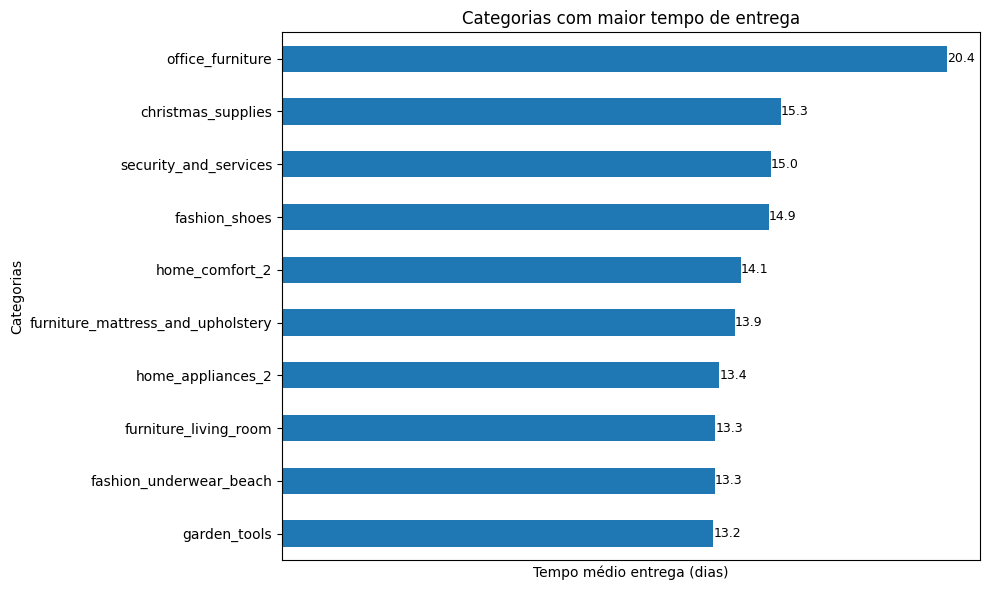

In [103]:
ax = categorias_tempo.sort_values(by='tempo_entrega', ascending=True).plot(kind='barh', figsize=(10, 6))
plt.title('Categorias com maior tempo de entrega')
plt.xlabel('Tempo médio entrega (dias)')
plt.ylabel('Categorias')

for bar in ax.patches:
    ax.text(
        bar.get_width(),                    
        bar.get_y() + bar.get_height() / 2, 
        f'{(bar.get_width()):,.1f}',
        va='center',
        ha='left',
        fontsize=9
    )

plt.legend().remove()
plt.xticks(rotation=45, ha='right')
plt.xticks([])
plt.tight_layout()
plt.show()

## 5. Purchase to Approval Time

In [104]:
# Qual o tempo medio entre compra e aprovacao do pedido?
df_logistics['tempo_aprovacao'] = (
    df_logistics['order_approved_at'] - df_logistics['order_purchase_timestamp']
).dt.total_seconds() / 3600

In [105]:
tempo_aprovacao = df_logistics.tempo_aprovacao.mean()
print(f"Tempo médio de aprovacao: {tempo_aprovacao:.2f} horas")

Tempo médio de aprovacao: 10.66 horas


## 6. Seller States with Most Delays

In [106]:
# Quais estados de vendedores tem mais atrasos?
atrasado_estado_vendedor = df_logistics[df_logistics['entrega_status'] == 'Atrasado'].groupby('seller_state')['entrega_status'].count().sort_values(ascending=False).to_frame().head(10)
atrasado_estado_vendedor

,entrega_status
seller_state,
SP,6698
PR,548
MG,477
RJ,380
SC,235
RS,97
MA,95
DF,59
BA,34


In [107]:
total_por_vendedor = df_logistics.groupby('seller_state')['entrega_status'].count()
atrasos_por_vendedor = df_logistics[df_logistics['entrega_status'] == 'Atrasado'].groupby('seller_state')['entrega_status'].count()

pct_atrasos_por_vendedor = (atrasos_por_vendedor / total_por_vendedor * 100).round(2).sort_values(ascending=False).to_frame().head(10)
pct_atrasos_por_vendedor

,entrega_status
seller_state,
AM,66.67
MA,23.46
PA,12.50
RN,10.71
CE,8.51
SP,8.34
MS,8.00
RJ,7.89
DF,6.56


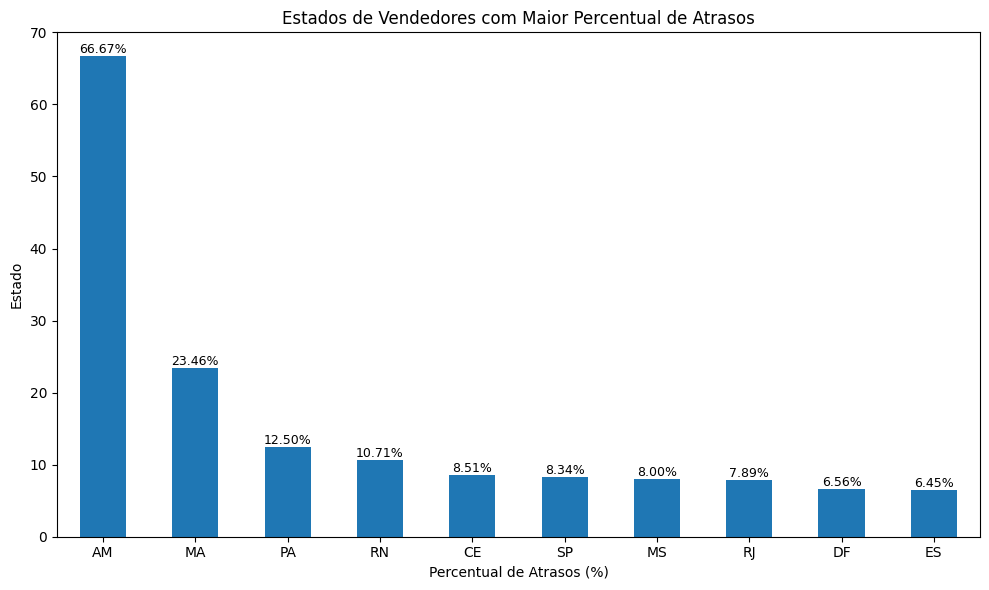

In [108]:
ax = pct_atrasos_por_vendedor.plot(kind='bar', figsize=(10,6))
plt.title('Estados de Vendedores com Maior Percentual de Atrasos')
plt.xlabel('Percentual de Atrasos (%)')
plt.ylabel('Estado')

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height(),                    
        f'{(bar.get_height()):,.2f}%',      
        va='bottom',
        ha='center',
        fontsize=9
    )

plt.xticks(rotation=0)
plt.legend().remove()
plt.tight_layout()
plt.show()

## 7. Distance vs Delivery Time

In [109]:
# Existe relacao entre distancia vendedor-cliente e tempo de entrega?
df_logistics['mesmo_estado'] = np.where(
    df_logistics['seller_state'] == df_logistics['customer_state'],
    'Mesmo Estado',
    'Estado Diferente'
)

df_logistics.groupby('mesmo_estado')['tempo_entrega'].mean().round(1).sort_values(ascending=False).to_frame()

,tempo_entrega
mesmo_estado,
Estado Diferente,14.6
Mesmo Estado,7.5


In [110]:
df_logistics.groupby(['seller_state', 'customer_state'])['tempo_entrega'].mean().round(1).sort_values(ascending=False).head(10).to_frame()

,,tempo_entrega
seller_state,customer_state,
CE,AM,138.0
AM,AL,90.0
BA,AC,66.0
ES,PA,36.3
RO,SE,36.0
BA,AM,33.0
GO,AM,32.0
PB,AL,31.0
MS,BA,30.7


In [111]:
df_logistics[(df_logistics['seller_state'] == 'CE') & (df_logistics['customer_state'] == 'AM')].shape

(1, 25)

> **Nota:** a rota CE → AM com 138 dias foi desconsiderada por representar
> apenas 1 pedido — outlier sem representatividade estatistica.

In [112]:
# Rotas com maior tempo de entrega - minimo 10 pedidos
rotas_tempo = (df_logistics
    .groupby(['seller_state', 'customer_state'])
    .filter(lambda x: len(x) >= 10).groupby(['seller_state', 'customer_state'])['tempo_entrega'].mean().round(1).sort_values(ascending=False)
    .head(10).to_frame())

rotas_tempo

tempo_entrega
seller_state customer_state               
PR           AL                       30.6
SP           RR                       30.0
             AP                       28.8
MA           ES                       28.0
SC           CE                       27.4
MG           PA                       27.3
RJ           RO                       27.2
SC           PB                       25.8
PR           AM                       25.7
SP           AM                       25.7

> **Insight:** as rotas com maior tempo de entrega conectam Sul/Sudeste ao
> Norte/Nordeste. SP → RR leva 30 dias em media, evidenciando o desafio
> logistico de atender regioes remotas do Brasil a partir dos principais
> centros de distribuicao.

## 8. Average Weight of Delayed Products

In [145]:
#Qual o peso medio dos produtos que mais atrasam?
produtos_pesados_atraso = (df_logistics[df_logistics['entrega_status'] == 'Atrasado'].groupby('product_category_name_english')
                            .agg(qtd_atraso=('entrega_status', 'count'),
                                 peso_medio=('product_weight_g', 'mean')).round(1).sort_values(by='qtd_atraso', ascending=False).head(10))

produtos_pesados_atraso

,qtd_atraso,peso_medio
product_category_name_english,,
bed_bath_table,920,2056.7
health_beauty,858,1077.2
furniture_decor,688,3358.0
sports_leisure,625,2020.5
computers_accessories,594,1132.7
watches_gifts,485,653.7
housewares,441,4244.9
telephony,369,271.6
auto,343,3428.8


> **Insight:** categorias com produtos mais pesados como furniture_decor (3.358g)
> e housewares (4.244g) apresentam mais atrasos, mas health_beauty com peso baixo
> (1.077g) tambem figura entre os mais atrasados pelo alto volume de vendas.

## 9. Delays by Month

In [147]:
# Quais meses tem mais atrasos?
mask = (df_logistics['order_purchase_timestamp'].dt.year == 2017)

atrasos_mes = (df_logistics[mask & (df_logistics['entrega_status'] == 'Atrasado')]
    .groupby(df_logistics[mask]['order_purchase_timestamp'].dt.month)['entrega_status']
    .count()
    .sort_values(ascending=False)
    .to_frame())

atrasos_mes.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
atrasos_mes

,entrega_status
Jan,1172
Feb,506
Mar,264
Apr,243
May,193
Jun,163
Jul,160
Aug,151
Sep,151
Oct,131


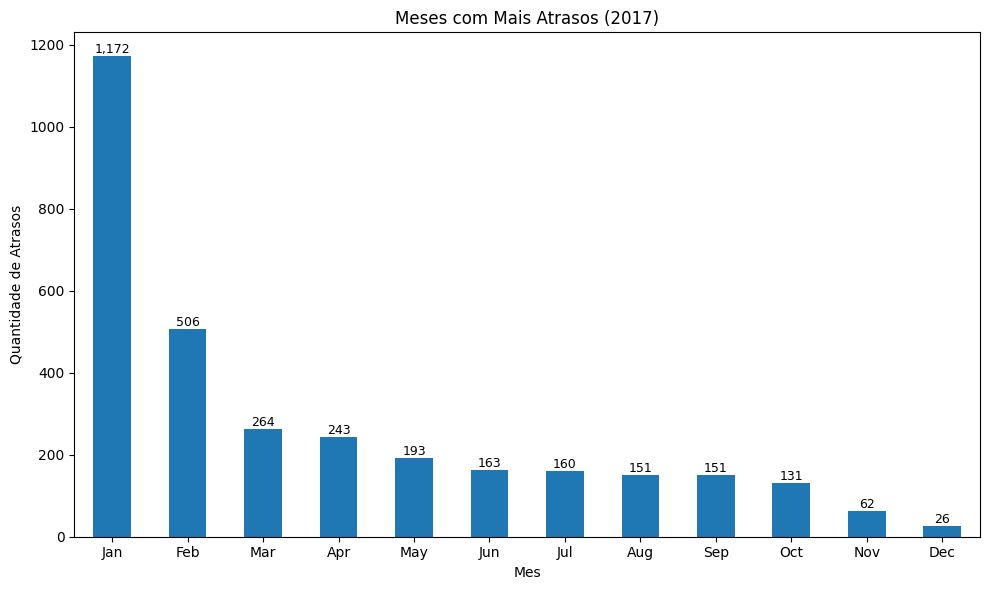

In [148]:
ax = atrasos_mes.sort_values(by='entrega_status', ascending=False).plot(kind='bar', figsize=(10, 6))
plt.title('Meses com Mais Atrasos (2017)')
plt.xlabel('Mes')
plt.ylabel('Quantidade de Atrasos')

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{int(bar.get_height()):,}',
        va='bottom',
        ha='center',
        fontsize=9
    )

plt.xticks(rotation=0)
plt.legend().remove()
plt.tight_layout()
plt.show()

## 10. Average Delivery Time by Category

In [149]:
# Qual o tempo medio de entrega por categoria de produto?
tempo_categoria = (df_logistics.groupby('product_category_name_english')['tempo_entrega']
    .mean()
    .round(1)
    .sort_values(ascending=False)
    .head(10)
    .to_frame())

tempo_categoria

,tempo_entrega
product_category_name_english,
office_furniture,20.4
christmas_supplies,15.3
security_and_services,15.0
fashion_shoes,14.9
home_comfort_2,14.1
furniture_mattress_and_upholstery,13.9
home_appliances_2,13.4
furniture_living_room,13.3
fashion_underwear_beach,13.3


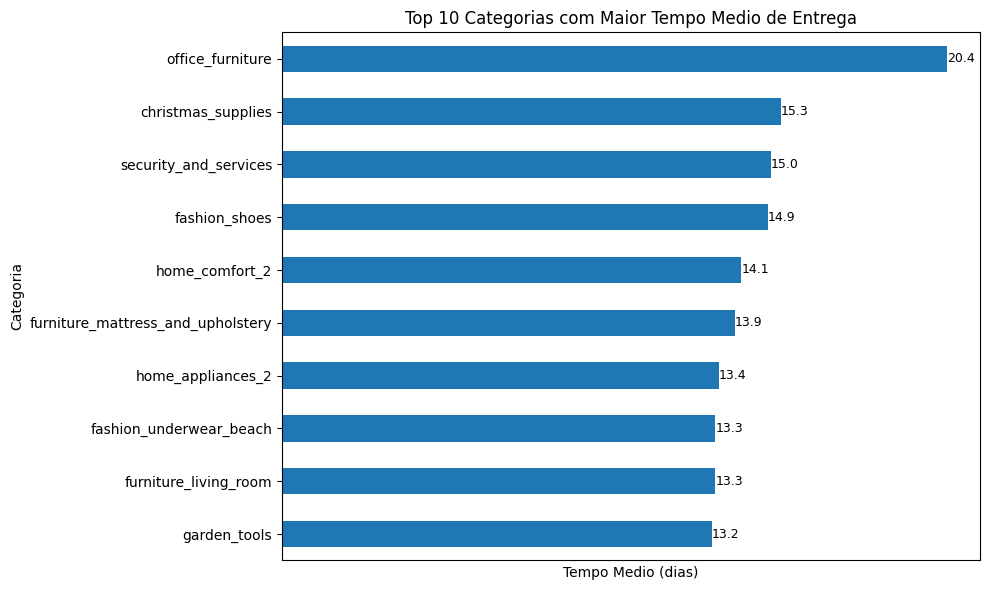

In [151]:
ax = tempo_categoria.sort_values(by='tempo_entrega', ascending=True).plot(kind='barh', figsize=(10, 6))
plt.title('Top 10 Categorias com Maior Tempo Medio de Entrega')
plt.xlabel('Tempo Medio (dias)')
plt.ylabel('Categoria')

for bar in ax.patches:
    ax.text(
        bar.get_width(),                    
        bar.get_y() + bar.get_height() / 2, 
        f'{(bar.get_width()):,.1f}',
        va='center',
        ha='left',
        fontsize=9
    )

plt.legend().remove()
plt.xticks(rotation=45, ha='right')
plt.xticks([])
plt.tight_layout()
plt.show()